# Patient Trajectory (Visit 1 to Visit n)

This notebook visualizes one patient timeline using `concepts_3d.json`.
It plots visit-wise follow-up tumor burden, SPD progression, and RANO labels.

In [1]:
from pathlib import Path
import json
import re

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
REPO_ROOT = Path('..').resolve().parent
CONCEPTS_PATH = REPO_ROOT / 'concepts_3d.json'

with open(CONCEPTS_PATH, 'r') as f:
    concepts_data = json.load(f)

policy = [
    'enhancing_tumor_volume_cm3',
    'non_enhancing_volume_cm3',
    'followup_enhancing_volume_cm3',
    'followup_non_enhancing_volume_cm3',
    'baseline_spd_cm2',
    'followup_spd_cm2',
    'time_gap',
    'delta_enhancing_absolute',
    'delta_enhancing_percent',
    'delta_non_enhancing_absolute',
    'delta_non_enhancing_percent',
    'delta_spd_absolute',
    'delta_spd_percent',
    'new_lesion_flag',
    'vol_pd_flag',
    'vol_pr_flag',
    'spd_pd_flag',
    'spd_pr_flag',
]

rano_map = {0: 'CR', 1: 'PR', 2: 'SD', 3: 'PD'}

In [3]:
def parse_week(case_name: str):
    m = re.search(r'week-(\d+)', case_name)
    return int(m.group(1)) if m else None

rows = []
for sample_id, item in concepts_data.items():
    row = {
        'sample_id': sample_id,
        'patient_id': item['patient_id'],
        'baseline_case': item['baseline_case'],
        'followup_case': item['followup_case'],
        'baseline_week': parse_week(item['baseline_case']),
        'followup_week': parse_week(item['followup_case']),
        'time_gap_years': item.get('time_gap', None),
        'rano_label_id': item['rano_label'],
        'rano_label': rano_map.get(item['rano_label'], str(item['rano_label'])),
    }
    row.update(dict(zip(policy, item['concepts'])))
    rows.append(row)

df = pd.DataFrame(rows)
counts = df.groupby('patient_id').size().sort_values(ascending=False)
counts.head(10)

patient_id
patient_056    15
patient_065    15
patient_061    15
patient_026    13
patient_006    11
patient_024    11
patient_060    11
patient_017    10
patient_014    10
patient_020     9
dtype: int64

In [4]:
# Set any patient_id shown above, e.g., 'patient_002'
SELECTED_PATIENT_ID = counts.index[0]
patient_df = (
    df[df['patient_id'] == SELECTED_PATIENT_ID]
    .sort_values(['followup_week', 'sample_id'])
    .reset_index(drop=True)
)

print(f'Patient: {SELECTED_PATIENT_ID} | visits: {len(patient_df)}')
patient_df[['sample_id', 'baseline_case', 'followup_case', 'baseline_week', 'followup_week', 'rano_label']].head(20)

Patient: patient_056 | visits: 15


,sample_id,baseline_case,followup_case,baseline_week,followup_week,rano_label
0,Patient-067_week-013,Patient-067_week-000-2,Patient-067_week-013,0,13,PD
1,Patient-067_week-033,Patient-067_week-019-2,Patient-067_week-033,19,33,PD
2,Patient-067_week-042,Patient-067_week-019-2,Patient-067_week-042,19,42,PD
3,Patient-067_week-053,Patient-067_week-019-2,Patient-067_week-053,19,53,PD
4,Patient-067_week-068,Patient-067_week-059,Patient-067_week-068,59,68,SD
5,Patient-067_week-073,Patient-067_week-059,Patient-067_week-073,59,73,SD
6,Patient-067_week-077,Patient-067_week-059,Patient-067_week-077,59,77,SD
7,Patient-067_week-079,Patient-067_week-059,Patient-067_week-079,59,79,SD
8,Patient-067_week-092,Patient-067_week-059,Patient-067_week-092,59,92,SD
9,Patient-067_week-109,Patient-067_week-059,Patient-067_week-109,59,109,PD


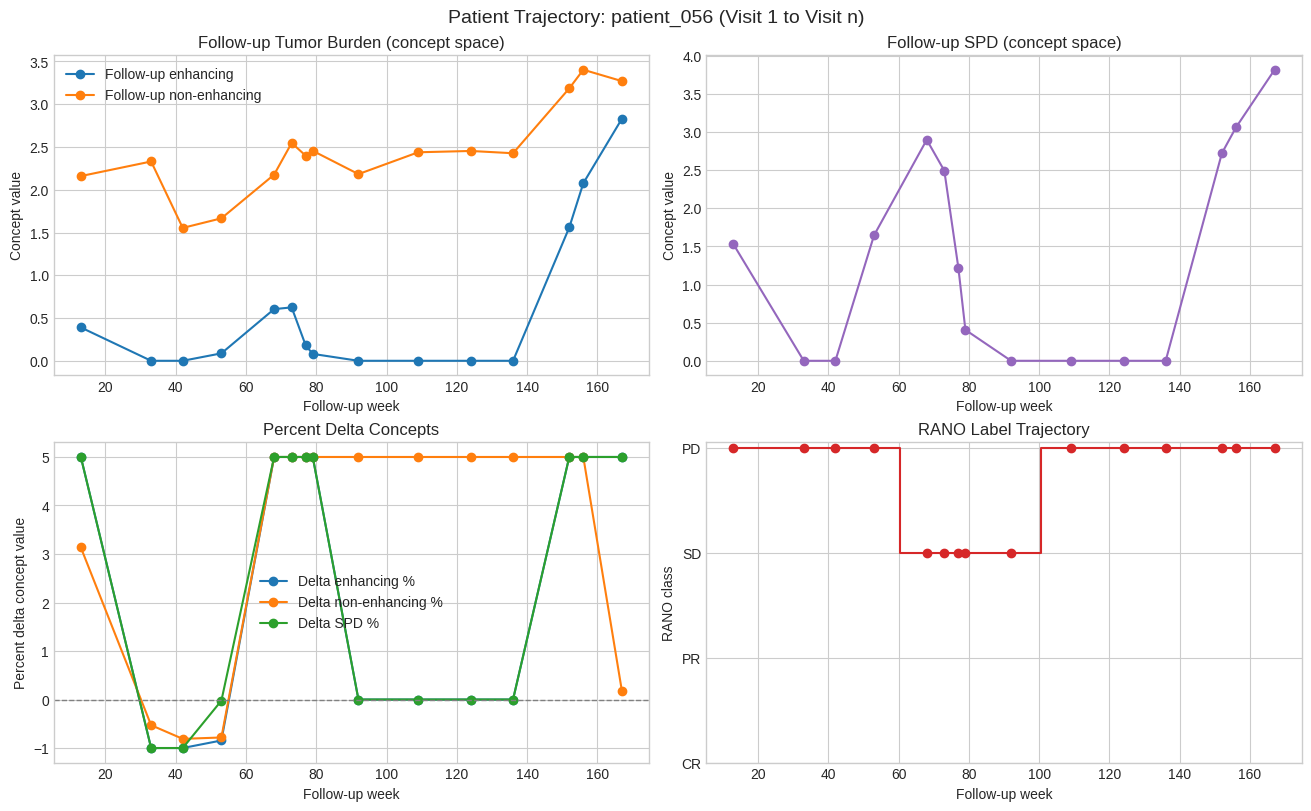

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
x = patient_df['followup_week']

axes[0, 0].plot(x, patient_df['followup_enhancing_volume_cm3'], marker='o', label='Follow-up enhancing')
axes[0, 0].plot(x, patient_df['followup_non_enhancing_volume_cm3'], marker='o', label='Follow-up non-enhancing')
axes[0, 0].set_title('Follow-up Tumor Burden (concept space)')
axes[0, 0].set_xlabel('Follow-up week')
axes[0, 0].set_ylabel('Concept value')
axes[0, 0].legend()

axes[0, 1].plot(x, patient_df['followup_spd_cm2'], marker='o', color='tab:purple')
axes[0, 1].set_title('Follow-up SPD (concept space)')
axes[0, 1].set_xlabel('Follow-up week')
axes[0, 1].set_ylabel('Concept value')

axes[1, 0].plot(x, patient_df['delta_enhancing_percent'], marker='o', label='Delta enhancing %')
axes[1, 0].plot(x, patient_df['delta_non_enhancing_percent'], marker='o', label='Delta non-enhancing %')
axes[1, 0].plot(x, patient_df['delta_spd_percent'], marker='o', label='Delta SPD %')
axes[1, 0].axhline(0, linestyle='--', linewidth=1, color='gray')
axes[1, 0].set_title('Percent Delta Concepts')
axes[1, 0].set_xlabel('Follow-up week')
axes[1, 0].set_ylabel('Percent delta concept value')
axes[1, 0].legend()

label_to_id = {'CR': 0, 'PR': 1, 'SD': 2, 'PD': 3}
y = patient_df['rano_label'].map(label_to_id)
axes[1, 1].step(x, y, where='mid', marker='o', color='tab:red')
axes[1, 1].set_title('RANO Label Trajectory')
axes[1, 1].set_xlabel('Follow-up week')
axes[1, 1].set_ylabel('RANO class')
axes[1, 1].set_yticks([0, 1, 2, 3], ['CR', 'PR', 'SD', 'PD'])

fig.suptitle(f'Patient Trajectory: {SELECTED_PATIENT_ID} (Visit 1 to Visit n)', fontsize=14)
plt.show()

In [6]:
patient_df[[
    'followup_case', 'followup_week', 'rano_label',
    'followup_enhancing_volume_cm3', 'followup_non_enhancing_volume_cm3',
    'followup_spd_cm2', 'delta_enhancing_percent', 'delta_non_enhancing_percent', 'delta_spd_percent'
]].sort_values('followup_week')

,followup_case,followup_week,rano_label,followup_enhancing_volume_cm3,followup_non_enhancing_volume_cm3,followup_spd_cm2,delta_enhancing_percent,delta_non_enhancing_percent,delta_spd_percent
0,Patient-067_week-013,13,PD,0.390013,2.159869,1.526056,5.000000,3.134602,5.000000
1,Patient-067_week-033,33,PD,0.000000,2.330492,0.000000,-0.999829,-0.529352,-0.999977
2,Patient-067_week-042,42,PD,0.000000,1.553714,0.000000,-0.999829,-0.810937,-0.999977
3,Patient-067_week-053,53,PD,0.087095,1.666007,1.644805,-0.844300,-0.782444,-0.023364
4,Patient-067_week-068,68,SD,0.604316,2.176568,2.897016,5.000000,5.000000,5.000000
5,Patient-067_week-073,73,SD,0.624333,2.547490,2.491551,5.000000,5.000000,5.000000
6,Patient-067_week-077,77,SD,0.178983,2.397713,1.217876,5.000000,5.000000,5.000000
7,Patient-067_week-079,79,SD,0.080658,2.455392,0.405465,5.000000,5.000000,5.000000
8,Patient-067_week-092,92,SD,0.000000,2.183013,0.000000,0.000000,5.000000,0.000000
9,Patient-067_week-109,109,PD,0.000000,2.438252,0.000000,0.000000,5.000000,0.000000


## Single-Visit Contribution and Score

This section explains one selected follow-up visit using a transparent contribution score built from clinically relevant concept values.

- Positive contributions increase progression evidence.
- Negative contributions decrease progression evidence.
- The total score is the sum of shown contributions for the selected visit.

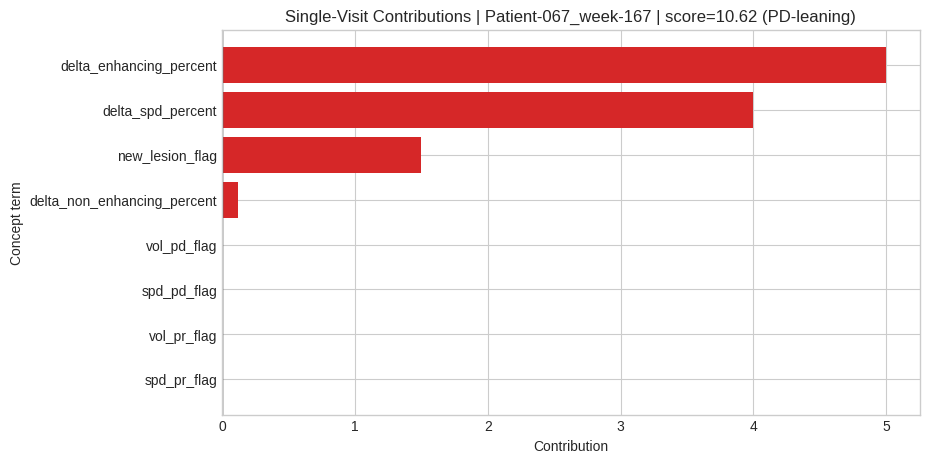

Selected visit index: -1
Score: 10.62 | Interpreted state: PD-leaning


,sample_id,followup_case,followup_week,rano_label,delta_enhancing_percent,delta_non_enhancing_percent,delta_spd_percent,new_lesion_flag,vol_pd_flag,vol_pr_flag,spd_pd_flag,spd_pr_flag
14,Patient-067_week-167,Patient-067_week-167,167,PD,5.0,0.169684,5.0,1.0,0.0,0.0,0.0,0.0


In [7]:
# Choose one visit row from patient_df (e.g., -1 is latest, 0 is first)
VISIT_INDEX = -1
visit = patient_df.iloc[VISIT_INDEX]

# Transparent contribution terms (heuristic, concept-space units)
# Positive terms push toward progression; negative terms push away.
contrib = {
    "delta_enhancing_percent": float(visit["delta_enhancing_percent"]),
    "delta_non_enhancing_percent": 0.7 * float(visit["delta_non_enhancing_percent"]),
    "delta_spd_percent": 0.8 * float(visit["delta_spd_percent"]),
    "new_lesion_flag": 1.5 * float(visit["new_lesion_flag"]),
    "vol_pd_flag": 1.2 * float(visit["vol_pd_flag"]),
    "spd_pd_flag": 1.2 * float(visit["spd_pd_flag"]),
    "vol_pr_flag": -1.0 * float(visit["vol_pr_flag"]),
    "spd_pr_flag": -1.0 * float(visit["spd_pr_flag"]),
}

score = sum(contrib.values())
pred_state = "PD-leaning" if score >= 1.0 else ("SD-leaning" if score >= -0.5 else "PR/CR-leaning")

contrib_df = (
    pd.DataFrame({"term": list(contrib.keys()), "contribution": list(contrib.values())})
    .sort_values("contribution")
    .reset_index(drop=True)
)

colors = ["tab:red" if v > 0 else "tab:blue" for v in contrib_df["contribution"]]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(contrib_df["term"], contrib_df["contribution"], color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_title(
    f"Single-Visit Contributions | {visit['followup_case']} | "
    f"score={score:.2f} ({pred_state})"
)
ax.set_xlabel("Contribution")
ax.set_ylabel("Concept term")
plt.show()

summary_cols = [
    "sample_id", "followup_case", "followup_week", "rano_label",
    "delta_enhancing_percent", "delta_non_enhancing_percent", "delta_spd_percent",
    "new_lesion_flag", "vol_pd_flag", "vol_pr_flag", "spd_pd_flag", "spd_pr_flag",
]

print(f"Selected visit index: {VISIT_INDEX}")
print(f"Score: {score:.2f} | Interpreted state: {pred_state}")
patient_df[summary_cols].iloc[[VISIT_INDEX]]

## Expert Causal Graph (Paper Figure 7)

Clinically sparse expert DAG used by the paper, rendered in the same style as `src/visualize.py::plot_causal_graph`.

- Blue boxes: clinical concepts (roots, deltas, RANO flags, time).
- Pink box: target node (`TreatmentResponse`).
- Green badge: ground-truth RANO label for the selected visit.
- Yellow badge: predicted state from the per-visit contribution score.

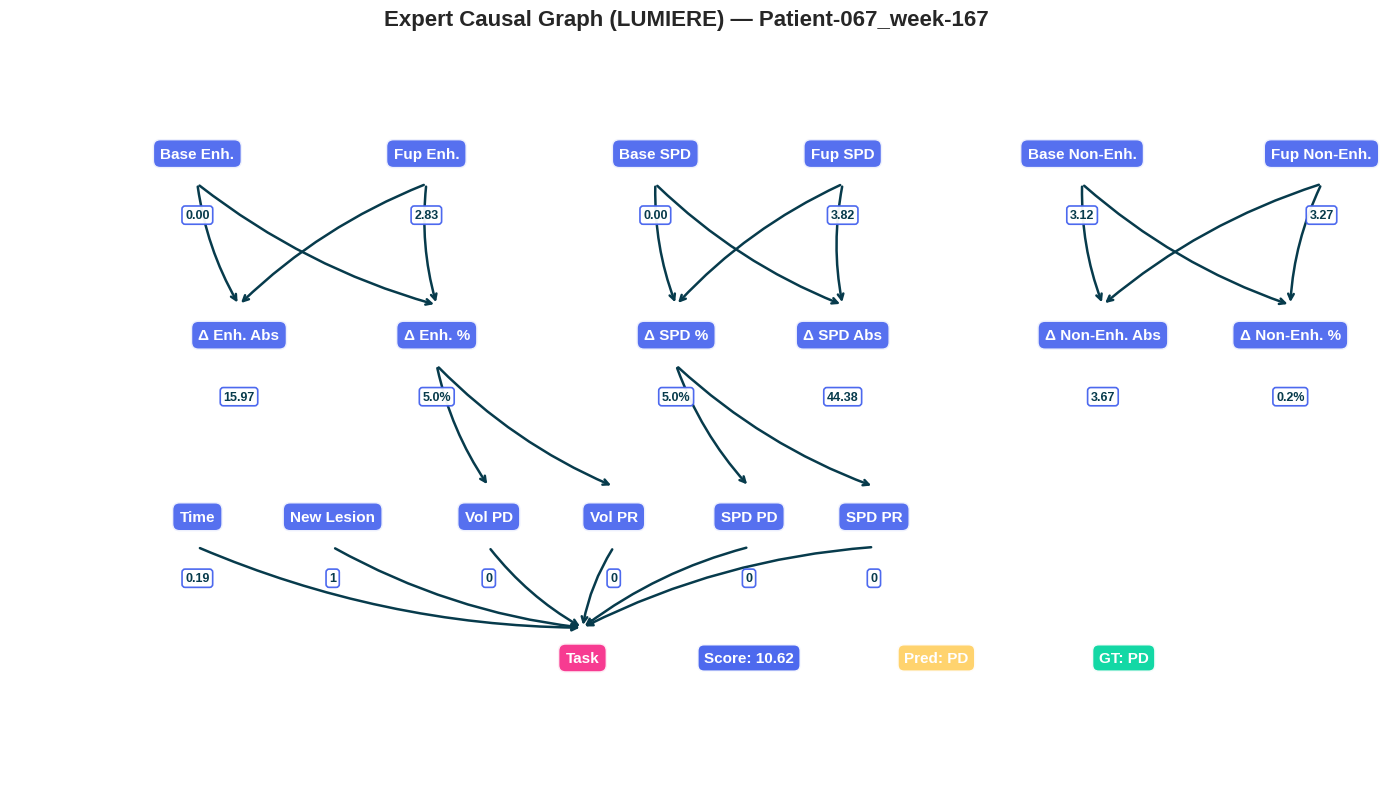

In [ ]:
# Expert causal DAG (paper Figure 7) — ported from src/visualize.py::plot_causal_graph
# Clean rounded-box nodes, short clinical labels, curved arrows. Adds GT and Pred
# badges next to the TreatmentResponse node for the selected visit.

COLORS = {
    "primary": "#4361ee",
    "accent": "#f72585",
    "dark": "#073b4c",
    "success": "#06d6a0",
    "warning": "#ffd166",
}

short = {
    "enhancing_tumor_volume_cm3": "Base Enh.",
    "non_enhancing_volume_cm3": "Base Non-Enh.",
    "followup_enhancing_volume_cm3": "Fup Enh.",
    "followup_non_enhancing_volume_cm3": "Fup Non-Enh.",
    "baseline_spd_cm2": "Base SPD",
    "followup_spd_cm2": "Fup SPD",
    "time_gap": "Time",
    "delta_enhancing_percent": "Δ Enh. %",
    "delta_non_enhancing_percent": "Δ Non-Enh. %",
    "delta_enhancing_absolute": "Δ Enh. Abs",
    "delta_non_enhancing_absolute": "Δ Non-Enh. Abs",
    "delta_spd_absolute": "Δ SPD Abs",
    "delta_spd_percent": "Δ SPD %",
    "new_lesion_flag": "New Lesion",
    "vol_pd_flag": "Vol PD",
    "vol_pr_flag": "Vol PR",
    "spd_pd_flag": "SPD PD",
    "spd_pr_flag": "SPD PR",
    "TreatmentResponse": "Task",
}

positions = {
    "enhancing_tumor_volume_cm3":         (0.8, 5.0),
    "followup_enhancing_volume_cm3":      (3.0, 5.0),
    "baseline_spd_cm2":                   (5.2, 5.0),
    "followup_spd_cm2":                   (7.0, 5.0),
    "non_enhancing_volume_cm3":           (9.3, 5.0),
    "followup_non_enhancing_volume_cm3":  (11.6, 5.0),
    "delta_enhancing_absolute":           (1.2, 3.2),
    "delta_enhancing_percent":            (3.1, 3.2),
    "delta_spd_percent":                  (5.4, 3.2),
    "delta_spd_absolute":                 (7.0, 3.2),
    "delta_non_enhancing_absolute":       (9.5, 3.2),
    "delta_non_enhancing_percent":        (11.3, 3.2),
    "time_gap":         (0.8, 1.4),
    "new_lesion_flag":  (2.1, 1.4),
    "vol_pd_flag":      (3.6, 1.4),
    "vol_pr_flag":      (4.8, 1.4),
    "spd_pd_flag":      (6.1, 1.4),
    "spd_pr_flag":      (7.3, 1.4),
    "TreatmentResponse": (4.5, 0.0),
}

edges = [
    ("enhancing_tumor_volume_cm3", "delta_enhancing_absolute"),
    ("enhancing_tumor_volume_cm3", "delta_enhancing_percent"),
    ("followup_enhancing_volume_cm3", "delta_enhancing_absolute"),
    ("followup_enhancing_volume_cm3", "delta_enhancing_percent"),
    ("non_enhancing_volume_cm3", "delta_non_enhancing_absolute"),
    ("non_enhancing_volume_cm3", "delta_non_enhancing_percent"),
    ("followup_non_enhancing_volume_cm3", "delta_non_enhancing_absolute"),
    ("followup_non_enhancing_volume_cm3", "delta_non_enhancing_percent"),
    ("baseline_spd_cm2", "delta_spd_absolute"),
    ("baseline_spd_cm2", "delta_spd_percent"),
    ("followup_spd_cm2", "delta_spd_absolute"),
    ("followup_spd_cm2", "delta_spd_percent"),
    ("delta_enhancing_percent", "vol_pd_flag"),
    ("delta_enhancing_percent", "vol_pr_flag"),
    ("delta_spd_percent", "spd_pd_flag"),
    ("delta_spd_percent", "spd_pr_flag"),
    ("time_gap", "TreatmentResponse"),
    ("new_lesion_flag", "TreatmentResponse"),
    ("vol_pd_flag", "TreatmentResponse"),
    ("vol_pr_flag", "TreatmentResponse"),
    ("spd_pd_flag", "TreatmentResponse"),
    ("spd_pr_flag", "TreatmentResponse"),
]

fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(-1, 14.5)
ax.set_ylim(-1.2, 6)
ax.axis("off")
ax.set_title(
    f"Expert Causal Graph (LUMIERE) — {visit['followup_case']}",
    fontsize=16, fontweight="bold", pad=20,
)

# Edges
for src, dst in edges:
    x1, y1 = positions[src]
    x2, y2 = positions[dst]
    ax.annotate(
        "",
        xy=(x2, y2 + 0.3),
        xytext=(x1, y1 - 0.3),
        arrowprops=dict(arrowstyle="->", color=COLORS["dark"], lw=1.8,
                        connectionstyle="arc3,rad=0.1"),
    )

# Nodes — show concept value and (if applicable) its contribution score for the visit.
def _fmt_node_value(name, visit):
    if name == "TreatmentResponse" or name not in visit.index:
        return None
    v = visit[name]
    try:
        fv = float(v)
    except (TypeError, ValueError):
        return str(v)
    if name.endswith("_flag"):
        return f"{int(fv)}"
    if "percent" in name:
        return f"{fv:.1f}%"
    return f"{fv:.2f}"

for name, (x, y) in positions.items():
    is_task = name == "TreatmentResponse"
    color = COLORS["accent"] if is_task else COLORS["primary"]
    bbox = dict(boxstyle="round,pad=0.5", facecolor=color, alpha=0.9,
                edgecolor="white", linewidth=2)
    ax.text(x, y, short[name], ha="center", va="center",
            fontsize=11, fontweight="bold", color="white", bbox=bbox)
    v_text = _fmt_node_value(name, visit)
    if v_text is not None:
        ax.text(
            x, y - 0.55, f"val: {v_text}", ha="center", va="top",
            fontsize=9, fontweight="bold", color=COLORS["dark"],
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white",
                      edgecolor=COLORS["primary"], linewidth=1.2, alpha=0.95),
        )
    if name in contrib:
        c = contrib[name]
        c_fc = COLORS["accent"] if c > 0 else (COLORS["success"] if c < 0 else COLORS["dark"])
        ax.text(
            x, y - 0.95, f"score: {c:+.2f}", ha="center", va="top",
            fontsize=9, fontweight="bold", color="white",
            bbox=dict(boxstyle="round,pad=0.25", facecolor=c_fc,
                      edgecolor="white", linewidth=1.2, alpha=0.95),
        )

# Score / Pred / GT badges side-by-side next to TreatmentResponse
gt_label = visit["rano_label"]
pred_label = pred_state.split("-")[0]   # PD / SD / PR/CR
tx, ty = positions["TreatmentResponse"]

badges = [
    (f"Score: {score:.2f}", COLORS["primary"]),
    (f"Pred: {pred_label}", COLORS["warning"]),
    (f"GT: {gt_label}",     COLORS["success"]),
]
badge_x0 = tx + 1.6
badge_dx = 1.8
for i, (text, fc) in enumerate(badges):
    ax.text(
        badge_x0 + i * badge_dx, ty, text,
        ha="center", va="center", fontsize=11, fontweight="bold", color="white",
        bbox=dict(boxstyle="round,pad=0.45", facecolor=fc,
                  edgecolor="white", linewidth=2, alpha=0.95),
    )

ax.set_xlim(-1, badge_x0 + len(badges) * badge_dx + 0.5)

plt.tight_layout()
plt.show()